In [1]:
# Most of this code is taken from the research module code 

In [2]:
%matplotlib inline

In [3]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote_2") # Site name given in the installation of Salvus flow
PROJECT_DIR = "simulation_wavefield_output_rupture_domain"  

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.35 seconds]


In [4]:
# # Delete entire project directory to clear all cached metadata
# import shutil
# if pathlib.Path(PROJECT_DIR).exists():
#     shutil.rmtree(PROJECT_DIR)
#     print(f"Deleted {PROJECT_DIR}")

In [5]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-05-06 12:27:03,269] INFO: Loading project from simulation_wavefield_output_rupture_domain.


In [6]:
# Layered model setup: three layers ordered as snow, weak layer (wl), air.

x_min, x_max = 0.0, 400.0

# Geometry (high y = top of domain ):
slab_bottom = 0.0
slab_thickness = 1.5
wl_thickness = 0.01 # doesnt matter right now because vp, vs and rho are the same as snow 
domain_top = 3.0

slab_top = slab_bottom + slab_thickness # snow-wl interface
wl_bottom = slab_top
wl_top = wl_bottom + wl_thickness #wl-air interface
air_top = domain_top

# Boundaries from top to bottom -> 3 layers.
layers_x = [
    np.array([x_min, x_max]),# top boundary
    np.array([x_min, x_max]),# air-wl interface
    np.array([x_min, x_max]),# wl-snow interface
    np.array([x_min, x_max]),# bottom boundary
]
layers_y = [
    np.array([air_top, air_top]),
    np.array([wl_top, wl_top]),
    np.array([wl_bottom, wl_bottom]),
    np.array([slab_bottom, slab_bottom]),
]

# Material parameters by region index [snow air].
vp = np.array([300.0, 300.0, 332.0, ]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)

max_frequency = 50.0
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
# print("Three-layer mesh built.")
# print(f"  Snow layer: y = [{slab_bottom:.2f}, {slab_top:.2f}] m, vs=150 m/s")
# print(f"  Weak layer: y = [{wl_bottom:.2f}, {wl_top:.2f}] m, vs=60 m/s")
# print(f"  Air layer:  y = [{wl_top:.2f}, {air_top:.2f}] m, vs=0 m/s")

In [7]:
# Soure located at the top of the domain 
src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
    x = 200, 
    y = 1.5, 
    mxx = 0, 
    myy = -1.09e+02, 
    mxy = 2.54e+02, 
)

p.add_to_project(sn.Event(event_name="event_wavefield_output", sources=[src]))

[2026-05-06 12:27:03,456] INFO: An event with name 'event_wavefield_output' and identical content already exists in the project. Nothing will be done.


In [8]:
# ec = sn.EventConfiguration(
#     wavelet=sn.simple_config.stf.Ricker(center_frequency=10), # THE SAME AS IN EVENT CONFIGUARTEIN: needs to be at least v/(thickness*4)
#     waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
    
#     ),
# )
# ec.wavelet.plot()

In [9]:
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name="sim_2d_layered",
        unstructured_mesh=mesh,
        event_configuration=sn.EventConfiguration(
            wavelet=sn.simple_config.stf.Ricker(
                center_frequency=10,
                time_shift_in_seconds=0.3  # shifts wavelet 
            ),
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=2.0,
            ),
        ),
    ),
)

[2026-05-06 12:27:03,560] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending on the mesh size) a large amount of data that has to be compared. So best only add it once!


In [10]:
# # For layered model 
# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         name="sim_2d_layered",
#         unstructured_mesh=mesh_2d_layered,
#         event_configuration=sn.EventConfiguration(
#         wavelet=sn.simple_config.stf.Ricker(center_frequency=10),
#         waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
#             start_time_in_seconds=-0.3,
#             end_time_in_seconds=10.0, 
#             ),
#         ),
#     ),
# )
# #p.viz.nb.simulation_setup("sim_2d_layered", events=["event_wavefield_output"])

In [48]:
# # List all simulations and their statuses
# p.simulations.list()

# Layered
p.simulations.launch(
    simulation_configuration="sim_2d_layered",
    events=p.events.list(),
    site_name="salome_remote_2", 
    ranks_per_job=4,
    extra_output_configuration={
        "volume_data": {
            "sampling_interval_in_time_steps": 50,
            "fields": ["velocity", "displacement"], # add displacement to field 
        },
    },
)
p.simulations.query(block=True)

[2026-05-06 11:21:05,850] INFO: Submitting job ...


Uploading 1 files...

🚀  Submitted job_2605061121853513_e72e5865fa@salome_remote_2


VBox()

True

In [12]:
# # Sublevel safe path for import of wavefield data
# import glob

# # Plotting wavefield output at one point in time
# out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

# # Memory-safe read: load every Nth stored time step instead of the full volume
# time_step_stride = 10

# # Dynamically find the volume_data_output.h5 file (path includes hash-based subdirs)
# import glob, os

# matches = glob.glob(str(out_2d_layered / "**" / "volume_data_output.h5"), recursive=True)
# for f in matches:
#     size_gb = os.path.getsize(f) / 1e9
#     print(f"{size_gb:.2f} GB  —  {f}")

# vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
#     h5_path,
#     "velocity",
#     "volume",
#     time_steps=slice(0, None, time_step_stride),
# )

# # Converting to an xarray on a regular plotting grid
# vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
#     vel_wo_layered,
#     points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
# )

# # Plotting wavefield output
# fig, ax = plt.subplots()
# plot_time_seconds = 0.8
# vel_2d_layered.sel(t=plot_time_seconds, method="nearest").isel(c=0).T.plot(
#     shading="gouraud",
#     infer_intervals=False,
# )
# ax.set_ylim(0, 3)
# ax.set_xlim(0, 30)
# ax.invert_yaxis()
# ax.set_ylabel("Depth (m)")
# ax.set_xlabel("Distance (m)")
# plt.show()

In [13]:
# Plotting wvaefield output at one point in time
out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

# Plotting wavefield output
# T is the timeslice (the t'th output image)
fig, ax = plt.subplots()
vel_2d_layered.isel(c=0, t=56).T.plot(shading="gouraud", infer_intervals=False)
ax.set_ylim(0,3)
ax.set_xlim(0,400)
ax.invert_yaxis()
ax.set_ylabel("Depth (m")
ax.set_xlabel("Distance (m)")
plt.show()


 


Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/24862 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20650 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 7 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-05-06 12:28:27,161] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
# plt.rcParams["animation.html"] = "jshtml"
# plt.rcParams["figure.dpi"] = 150
# plt.ioff()

# # getting wavefield output like above
# out_2d_layered = p.simulations.get_simulation_output_directory(
#     "sim_2d_layered", "event_wavefield_output"
# )

# vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
#     pathlib.Path(out_2d_layered, "volume_data_output.h5"),
#     "velocity",
#     "volume",
# )
# vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
#     vel_wo_layered,
#     points=[
#         np.linspace(0, 30, 101),  # width (m)
#         np.linspace(0, 3, 101),   # height (m)
#     ],
# )

# # Setting up animation
# fig, ax = plt.subplots()


# def animate(t):
#     for coll in ax.collections:
#         coll.remove()

#     vel_2d_layered.isel(c=1, t=t).T.plot(
#         ax=ax,
#         shading="gouraud",
#         infer_intervals=False,
#         add_colorbar=False,
#     )

#     # Force axis limits
#     ax.set_ylim(0,3)
#     ax.set_xlim(0,30)
#     ax.invert_yaxis()
#     ax.set_ylabel("Depth (m")
#     ax.set_xlabel("Distance (m)")
#     #ax.set_aspect("equal")
#     # ax.set_ylim(0.35, 1.0)
    
#     # Kill autoscaling 
#     ax.set_autoscale_on(False)

#     ax.set_title(f"Velocity field (t = {t})")


#     # Creating animation
# ani_layered = animation.FuncAnimation(
#     fig,
#     animate,
#     frames=vel_2d_layered.sizes["t"],
#     interval=100 # chnage interval to a higherr value for slower animation
# )

# ani_layered



In [15]:

# Define receiver line at snow-earth interface
y_surface = 3 * 2 / 3  # middle of snow layer 
#y_surface = 3 * 1 / 3 # snow-air interface
x_line = np.linspace(0.0, 400.0, 1001)
y_line = np.full_like(x_line, y_surface)

# Extract wavefield along receiver line
vel_sg = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=np.column_stack((x_line, y_line)),
)

# Select vertical component and full time range
sg_vy = vel_sg.isel(c=1)

t_vals = sg_vy.t.values
data = sg_vy.values  # shape: (n_t, n_points)

print("t range:", t_vals[0], "->", t_vals[-1])
print("data shape:", data.shape)

# Clip colorscale (robust equivalent)
vmax = np.percentile(np.abs(data), 95)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    x_line, t_vals, data,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax, vmax=vmax,
)
ax.invert_yaxis()
ax.axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=15")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(0, 400)
ax.set_title("Seismic waterfall plot - vertical particle velocity at halfway depth in snow (middle of snow layer)")
#ax.set_title("Seismic waterfall plot - vertical particle velocity at snow-earth interface")
ax.legend()
plt.colorbar(im, ax=ax, label="Vertical particle velocity (m/s)")
plt.tight_layout()
plt.show()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/3 [00:00<?, ?it/s]

t range: -0.3 -> 2.000053711051527
data shape: (9422, 1001)


/tmp/ipykernel_2167737/2525350267.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


In [16]:
# Only plot t=0 to 0.6s where the action is
sg_vy_zoom = sg_vy.sel(t=slice(0.0, 0.6))
t_vals = sg_vy_zoom.t.values
data = sg_vy_zoom.values

vmax = np.percentile(np.abs(data), 95)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(x_line, t_vals, data, shading="gouraud", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.invert_yaxis()
ax.axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=15")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(0, 300)
ax.set_title("Seismic waterfall zoomed to active window")
ax.legend()
plt.colorbar(im, ax=ax, label="Vertical particle velocity (m/s)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2167737/2467026883.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


In [17]:

# extract raw data
crds     = vel_wo_layered.crds  # (n_elements, n_nodes, 2)
data_raw = vel_wo_layered.data  # (n_time, n_elements, n_components, n_nodes)
t_sr     = vel_wo_layered.sampling_rate
t_start  = vel_wo_layered.start_time

# flatten coordinates to (N_points, 2)
n_elem, n_node, _ = crds.shape
xy_flat = crds.reshape(-1, 2)
x_pts   = xy_flat[:, 0]
y_pts   = xy_flat[:, 1]

# number of time steps and time axis
n_t    = data_raw.shape[0]
t_vals = t_start + np.arange(n_t) / t_sr

# vy component flattened to (n_t, N_points)
vy_flat = data_raw[:, :, 1, :].reshape(n_t, -1)

# coordinate setup: salvus coordinates do not match initially defined model coordinates
y_min_s = y_pts.min()  # 1.0 in Salvus coords
y_max_s = y_pts.max()  # 99.8 in Salvus coords
x_min_s = x_pts.min()  # -16.5
x_max_s = x_pts.max()  # 316.5
scale   = (y_max_s - y_min_s) / 3.0  # Salvus units per model metre

# interface and source positions in Salvus coordinates
y_interface_snow_firn = y_min_s + (3 * 1 / 3) * scale
y_interface_firn_bed  = y_min_s + (3 * 2 / 3) * scale
y_source_s            = y_min_s + 1.5 * scale
x_source_s            = 150.0

# grid interpolation
nx, ny = 300, 80
x_grid = np.linspace(x_min_s, x_max_s, nx)
y_grid = np.linspace(y_min_s, y_max_s, ny)
xx, yy = np.meshgrid(x_grid, y_grid)

# time subsampling
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 2  # increase to speed up, decrease for smoother animation
t_idx = np.arange(t_start_idx, n_t, N)

print(f"x range:        {x_min_s:.1f} -> {x_max_s:.1f} m")
print(f"y range:        {y_min_s:.1f} -> {y_max_s:.1f} m")
print(f"scale:          {scale:.2f} Salvus units per model metre")
print(f"t range:        {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"t_start_idx:    {t_start_idx} (t={t_vals[t_start_idx]:.3f} s)")
print(f"frames to anim: {len(t_idx)}")
print(f"snow-soil:      y = {y_interface_snow_firn:.2f} (model 1.0 m)")
print(f"bottom of soil: y = {y_interface_firn_bed:.2f} (model 2.0 m)")
print(f"source:         x = {x_source_s:.1f}, y = {y_source_s:.2f} (model 1.5 m)")


# background thread function for animation
def run_animation():
    from matplotlib import colors

    print("Pre-interpolating frames...", flush=True)
    frames_2d = []
    for k, i in enumerate(t_idx):
        grid_vals = griddata(
            xy_flat,
            vy_flat[i],
            (xx, yy),
            method="linear",
            fill_value=0.0,
        )
        frames_2d.append(grid_vals.astype(np.float64))
        if k % 20 == 0:
            print(f"  frame {k}/{len(t_idx)}  t={t_vals[i]:.3f} s", flush=True)

    frames_2d = np.asarray(frames_2d)  # (n_frames, ny, nx)
    frames_2d = np.nan_to_num(frames_2d, nan=0.0, posinf=0.0, neginf=0.0)

    # Robust color scaling for visibility: ignore tiny values and clip outliers.
    warmup = max(1, len(frames_2d) // 4)
    abs_vals = np.abs(frames_2d[warmup:]).ravel()
    abs_vals = abs_vals[np.isfinite(abs_vals)]

    # Drop near-zero amplitudes so percentiles are not dominated by silence.
    abs_vals = abs_vals[abs_vals > 1e-14]

    if abs_vals.size == 0:
        vmax = 1e-8
        linthresh = 1e-10
    else:
        vmax = float(np.percentile(abs_vals, 99.5))
        vmax = max(vmax, 1e-8)
        linthresh = max(float(np.percentile(abs_vals, 70)), vmax * 1e-3, 1e-10)

    norm = colors.SymLogNorm(
        linthresh=linthresh,
        vmin=-vmax,
        vmax=vmax,
        base=10,
    )
    print(f"Color scaling: vmax={vmax:.3e}, linthresh={linthresh:.3e}", flush=True)

    fig, ax = plt.subplots(figsize=(14, 5))

    im = ax.imshow(
        frames_2d[0],
        extent=[x_grid[0], x_grid[-1], y_grid[-1], y_grid[0]],
        aspect="auto",
        cmap="RdBu_r",
        norm=norm,
        origin="upper",
        interpolation="nearest",
    )

    # interface lines
    ax.axhline(y_interface_snow_firn, color="black", lw=1.2,
               linestyle="--", label="air-snow (1.0 m)")
    ax.axhline(y_interface_firn_bed, color="gray", lw=1.2,
               linestyle="--", label="snow-soil (2.0 m)")

    # source marker
    ax.plot(x_source_s, y_source_s, "v", color="teal",
            ms=8, label="source (x=150, y=1.5 m)")

    # y axis ticks in real model coordinates
    model_depths = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    salvus_y_ticks = [y_min_s + d * scale for d in model_depths]
    ax.set_yticks(salvus_y_ticks)
    ax.set_yticklabels([f"{d} m" for d in model_depths])

    ax.set_xlabel("x (m)")
    ax.set_ylabel("Depth (m)")
    ax.set_ylim(y_grid[-1], y_grid[0])
    ax.legend(loc="upper right", fontsize=8)
    plt.colorbar(im, ax=ax,
                 label="Vertical particle velocity vy (m/s)",
                 shrink=0.8)
    title = ax.set_title(f"Wavefield - t = {t_vals[t_start_idx]:.4f} s")
    plt.tight_layout()

    def update(frame_idx):
        im.set_data(frames_2d[frame_idx])
        title.set_text(f"Wavefield - t = {t_vals[t_idx[frame_idx]]:.4f} s")
        return im, title

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(t_idx),
        interval=40,
        blit=True,
    )

    # save animation with writer fallback
    print("Saving animation...", flush=True)
    if animation.writers.is_available("ffmpeg"):
        writer = animation.FFMpegWriter(
            fps=30,
            codec="libx264",
            extra_args=["-pix_fmt", "yuv420p"],
        )
        out_name = "wavefield_2d.mp4"
    else:
        writer = animation.PillowWriter(fps=20)
        out_name = "wavefield_2d.gif"

    ani.save(
        out_name,
        writer=writer,
        dpi=120,
        progress_callback=lambda i, n: print(
            f"  saving frame {i}/{n}", flush=True
        ) if i % 50 == 0 else None,
    )
    plt.close(fig)
    print(f"Done! Saved as {out_name}", flush=True)


# launch background thread
thread = threading.Thread(target=run_animation)
thread.start()
print("Animation running in background thread.")
print("Check progress with: thread.is_alive()")

x range:        -16.5 -> 416.5 m
y range:        1.5 -> 3.0 m
scale:          0.50 Salvus units per model metre
t range:        -0.300 -> 2.000 s
t_start_idx:    1229 (t=0.000 s)
frames to anim: 4097
snow-soil:      y = 2.00 (model 1.0 m)
bottom of soil: y = 2.50 (model 2.0 m)
source:         x = 150.0, y = 2.25 (model 1.5 m)
Pre-interpolating frames...
Animation running in background thread.
Check progress with: thread.is_alive()


In [18]:
# dt         = float(vel_sg.t.diff("t").mean())
# start_time = float(vel_sg.t.min())
# end_time   = float(vel_sg.t.max())
# fs         = 1.0 / dt
# n_samples  = vel_sg.sizes["t"]

# print(f"start_time: {start_time:.6f} s")
# print(f"end_time:   {end_time:.6f} s")
# print(f"dt:         {dt:.8f} s")
# print(f"fs:         {fs:.2f} Hz")
# print(f"Nyquist:    {fs/2:.2f} Hz")
# print(f"n_samples:  {n_samples}")

# # check if wavelet is properly contained
# f0 = 10.0
# t_needed = -2.0 / f0   # = -0.2 s minimum start time
# print(f"\nWavelet needs start_time <= {t_needed:.3f} s")
# print(f"Your start_time is {start_time:.3f} s")
# print(f"Wavelet contained: {start_time <= t_needed}")

In [19]:
# # plotting seismogram for a single ppoint
# single_trace = sg_vy.sel(point=0.0, method="nearest")  # far-field receiver
# plt.plot(single_trace.t, single_trace.values)
# plt.xlabel("Time (s)")
# plt.ylabel("vᵧ (m/s)")
# plt.title("Far-field seismogram at x=0")
# plt.show()

# #  plotting frequency content 
# from numpy.fft import rfft, rfftfreq
# dt = float(single_trace.t.diff("t").mean())
# spectrum = np.abs(rfft(single_trace.values))
# freqs    = rfftfreq(len(single_trace), d=dt)
# plt.figure()
# plt.plot(freqs, spectrum)
# plt.xlabel("Frequency (Hz)")
# plt.xlim(0, 100)
# plt.title("Frequency spectrum of far-field signal")
# plt.show()

# try several receiver positions and compare
positions = [2.0, 5.0, 10.0, 20.0, 25.0]
fig, axes = plt.subplots(len(positions), 1, figsize=(10, 12), sharex=True)
for ax, x_recv in zip(axes, positions):
    trace = sg_vy.sel(point=x_recv, method="nearest")  # reuses strided sg_vy
    ax.plot(trace.t, trace.values, lw=0.8, color="magenta")
    ax.set_ylabel("vᵧ (m/s)", fontsize=8)
    ax.set_title(f"x = {x_recv} m  (offset from source = {abs(x_recv - 15):.0f} m)", fontsize=9)
    ax.axhline(0, color="gray", lw=0.4)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Single traces at different receiver positions", y=1.01)
plt.tight_layout()
plt.show()

  frame 0/4097  t=0.000 s


In [20]:

# Extracting trace — picking far from source so source doesn't dominate
#  for Welch/STFT, dense time sampling matters. If the stride of 100
# gives too coarse a dt, reload vel_wo_layered with a smaller stride here.
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Raw seismogram
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram - x=0 m")
axes[0].axhline(0, color="gray", lw=0.5)

# Power Spectral Density (Welch method)
nperseg = min(1024, len(y_vals) // 4)
freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",      # reduces spectral leakage
    scaling="density",  # units: (m/s)^2/Hz
)
axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# Spectrogram (STFT)
nperseg_stft = min(512, len(y_vals) // 8)
freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,  # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)
Sxx_log = 10 * np.log10(Sxx + 1e-40)  # dB, small floor to avoid log(0)
im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) - x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")
plt.suptitle("Single trace frequency analysis - receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()

Sampling frequency: 4096.0 Hz
Nyquist frequency:  2048.0 Hz


In [21]:
# Plotting the same but with a bandpass filter
# Bandpass-enabled single-trace + PSD + spectrogram
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_raw = trace.values

# sampling properties
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

def bandpass(trace_in, fs, f_low=5.0, f_high=20.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = fs / 2.0
    f_low = max(f_low, 1e-6)
    f_high = min(f_high, 0.999 * nyq)
    if not (0 < f_low < f_high < nyq):
        raise ValueError(f"Invalid bandpass: f_low={f_low}, f_high={f_high}, Nyquist={nyq}")
    sos = signal.butter(order, [f_low / nyq, f_high / nyq], btype="band", output="sos")
    return signal.sosfiltfilt(sos, trace_in)

# choose pass-band here
f_low, f_high = 5.0, 20.0
y_filt = bandpass(y_raw, fs=fs, f_low=f_low, f_high=f_high, order=4)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 1) time series
axes[0].plot(t_vals, y_raw, lw=0.8, color="gray", alpha=0.7, label="Raw")
axes[0].plot(t_vals, y_filt, lw=1.0, color="magenta", label=f"Bandpassed ({f_low}-{f_high} Hz)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram - x=0 m")
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].legend()

# 2) PSD
nperseg = min(1024, len(y_raw) // 4)
freqs_psd_raw, psd_raw = signal.welch(
    y_raw,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
freqs_psd_filt, psd_filt = signal.welch(
    y_filt,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)

axes[1].semilogy(freqs_psd_raw, psd_raw, color="gray", alpha=0.7, label="Raw")
axes[1].semilogy(freqs_psd_filt, psd_filt, color="magenta", label=f"Bandpassed ({f_low}-{f_high} Hz)")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# 3) STFT spectrogram of filtered signal
nperseg_stft = min(512, len(y_filt) // 8)
freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_filt,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)

Sxx_log = 10 * np.log10(Sxx + 1e-40)
im = axes[2].pcolormesh(t_stft, freqs_stft, Sxx_log, shading="gouraud", cmap="vanimo")
axes[2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title(f"Spectrogram (STFT) — bandpassed {f_low}-{f_high} Hz, x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis - receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()

Sampling frequency: 4096.0 Hz
Nyquist frequency:  2048.0 Hz


In [22]:

# Wiggle plot form shotgather
sg = vel_sg.isel(c=1)  # component to plot (vx/vy)
rec_dim = [d for d in sg.dims if d != "t"][0]
sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
sg_tx = sg.transpose("t", "x")  # [time, distance]

t = sg_tx["t"].values
x = sg_tx["x"].values
A = sg_tx.values  # shape: [nt, nx]

# Plot settings
trace_step = 30  # plotting  every Nth receiver 
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()
    x0 = x[i]

 # normalization per trace by its own maximum s that wiggles can be seen 
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:      # skip dead traces
        continue
    tr /= tr_max

    # optional: clip wild amplitudes at early time
    #tr = np.clip(tr, -1, 1)

    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale)
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title("Wiggle shot gather — y=2.0 m")
plt.tight_layout()
plt.show()


In [23]:
def bandpass(trace, fs, f_low=1.0, f_high=30.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = fs / 2
    sos = signal.butter(
        order,
        [f_low / nyq, f_high / nyq],
        btype="band",
        output="sos"
    )
    return signal.sosfiltfilt(sos, trace)  # sosfiltfilt = zero phase, no time shift

# compute sampling frequency from time axis
dt = float(np.diff(t).mean())
fs = 1.0 / dt

trace_step   = 30
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()

   # bandpass filter: filters out frequencies above and below a certain frequency
   # f_low: klow frequency threshold 
   # f_high: high frequency threshold 
    tr = bandpass(tr, fs, f_low=5.0, f_high=20.0, order=4)

    # per-trace normalisation
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:
        continue
    tr /= tr_max
    tr  = np.clip(tr, -1, 1)

    x0   = x[i]
    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale) # automatically adjust xlim to fit wigglkes
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title(f"Wiggle shot gather - y=2.0 m  [bandpass {5}-{20} Hz]")
plt.tight_layout()
plt.show()

In [24]:
# Plotting code for displacement field
# Plotting wvaefield output at one point in time
out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

dis_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered,
        "volume_data_output.h5",
    ),
    "displacement",
    "volume",
)

# Converting to an x array
dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered,
    points=[np.linspace(0, 300, 101), np.linspace(0, 3, 101)],
)

# Plotting wavefield output
# T is the timeslice (the t'th output image)
fig, ax = plt.subplots()
dis_2d_layered.isel(c=0, t=56).T.plot(shading="gouraud", infer_intervals=False)
ax.set_ylim(0,3)
ax.set_xlim(0,30)
ax.invert_yaxis()
ax.set_ylabel("Depth (m")
ax.set_xlabel("Distance (m)")
plt.show()


 


Finding enclosing elements (pass 1 of auto):   0%|          | 0/10201 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/6262 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/5350 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/5050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/5050 [00:00<?, ?it/s]

...

  frame 20/4097  t=0.310 s


Finding enclosing elements (pass 8 of auto):   0%|          | 0/5050 [00:00<?, ?it/s]

[2026-05-06 12:30:09,127] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 5050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

  frame 40/4097  t=0.320 s


In [25]:
# plt.rcParams["animation.html"] = "jshtml"
# plt.rcParams["figure.dpi"] = 150
# plt.ioff()

# # getting wavefield output like above
# out_2d_layered = p.simulations.get_simulation_output_directory(
#     "sim_2d_layered", "event_wavefield_output"
# )

# dis_wo_layered = wavefield_output.WavefieldOutput.from_file(
#     pathlib.Path(out_2d_layered, "volume_data_output.h5"),
#     "displacement",
#     "volume",
# )
# dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
#     dis_wo_layered,
#     points=[
#         np.linspace(0, 300, 101),  # width (m)
#         np.linspace(0, 3, 101),   # height (m)
#     ],
# )

# # Setting up animation
# fig, ax = plt.subplots()


# def animate(t):
#     for coll in ax.collections:
#         coll.remove()

#     dis_2d_layered.isel(c=1, t=t).T.plot(
#         ax=ax,
#         shading="gouraud",
#         infer_intervals=False,
#         add_colorbar=False,
#     )

#     # Force axis limits
#     ax.set_ylim(0,3)
#     ax.set_xlim(0,300)
#     ax.invert_yaxis()
#     ax.set_ylabel("Depth (m")
#     ax.set_xlabel("Distance (m)")
#     #ax.set_aspect("equal")
#     # ax.set_ylim(0.35, 1.0)
    
#     # Kill autoscaling 
#     ax.set_autoscale_on(False)

#     ax.set_title(f"Displacement field (t = {t})")


#     # Creating animation
# ani_layered = animation.FuncAnimation(
#     fig,
#     animate,
#     frames=dis_2d_layered.sizes["t"],
#     interval=100 # chnage interval to a higherr value for slower animation
# )

# ani_layered



In [26]:
y_surface = 3 * 1 / 3
x_line = np.linspace(0.0, 300.0, 1001)
y_line = np.full_like(x_line, y_surface)

dis_sg = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered,
    points=np.column_stack((x_line, y_line)),
)
# vy is vertical particle velocity — most sensitive to P-wave arrivals
sg_vy = dis_sg.isel(c=1).sel(t=slice(0, 2.0))
sg_vy["point"] = x_line  # distance in m along x 

sg_vy.plot(
    x="point",
    y="t",
    shading="gouraud",
    infer_intervals=False,
    cbar_kwargs= {"label": "Vertical particle displacement (m)", "shrink": 0.8,},
    yincrease=False,
    robust=True,# this clips colorscale so that the source doesnt dominate the plot and the other waves can be seen 
)
plt.xlabel("x (m)")
plt.ylabel("Time (s)")
plt.axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=150") # add vertical line to source location for easier interpretation (can also be commented)
plt.title("Seismic waterfall plot below source location at 1m depth in snow")
plt.show()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

[2026-05-06 12:30:12,200] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 1001 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid: 0it [00:00, ?it/s]

  frame 60/4097  t=0.329 s


In [27]:

# Extracting trace, picking trace far away from source so that source doesnt dominate
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# PLotting raw seismogram 
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("displacement (m)")
axes[0].set_title("Seismogram — x=0 m")
axes[0].axhline(0, color="gray", lw=0.5) 

#  Power Spectral Density (Welch method)
# Welch averages many overlapping windows 
# nperseg controls frequency resolution: longer = finer freq bins
nperseg = min(1024, len(y_vals) // 4)

freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",           # hann window reduces spectral leakage
    scaling="density",       # units ms^2/HZ
)

axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# spectrogram 
# nperseg_stft controls the time/frequency resolution tradeoff:
# longer window --< finer frequency resolution, coarser time resolution
#  shorter window --> finer time resolution, coarser frequency resolution
# aim fabput ~3-5 cycles of  lowest frequency of interest per window --> CHANGE THIS DEPENDING ON WHICH FREQUENCY 
nperseg_stft = min(512, len(y_vals) // 8)

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,   # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)

#log scale for amplitude — seismic signals span many orders of magnitude
Sxx_log = 10 * np.log10(Sxx + 1e-40)   # dB, small floor to avoid log(0)

im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) — x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))   # cap at 100 Hz or Nyquist
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis — receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()

Sampling frequency: 4096.0 Hz
Nyquist frequency:  2048.0 Hz


In [28]:

# Wiggle plot form shotgather
sg = dis_sg.isel(c=1)  # component to plot (vx/vy)
rec_dim = [d for d in sg.dims if d != "t"][0]
sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
sg_tx = sg.transpose("t", "x")  # [time, distance]

t = sg_tx["t"].values
x = sg_tx["x"].values
A = sg_tx.values  # shape: [nt, nx]

# Plot settings
trace_step = 30  # plotting  every Nth receiver 
wiggle_scale = 0.7 * np.median(np.diff(x)) * trace_step

fig, ax = plt.subplots(figsize=(14, 8))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()
    x0 = x[i]

 # normalization per trace by its own maximum s that wiggles can be seen 
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:      # skip dead traces
        continue
    tr /= tr_max

    # optional: clip wild amplitudes at early time
    #tr = np.clip(tr, -1, 1)

    xwig = x0 + wiggle_scale * tr

    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale)
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title("Wiggle shot gather — y=2.0 m")
plt.tight_layout()
plt.show()


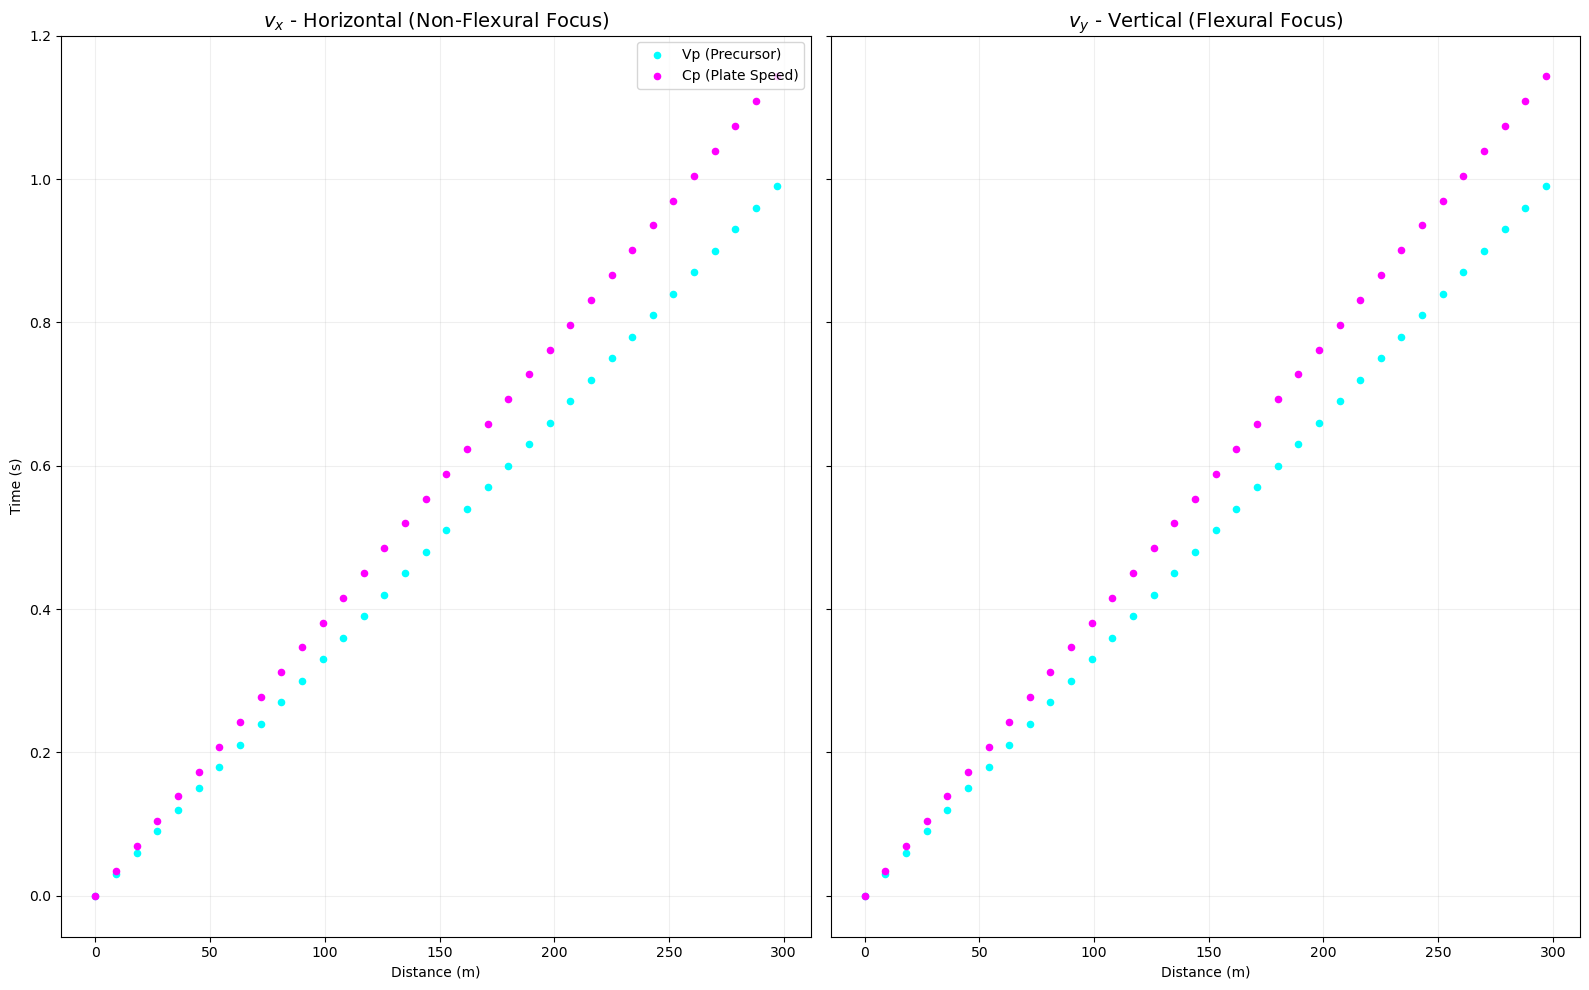

Comparison: Vp = 300.0 m/s | Cp (Non-flexural) = 259.81 m/s


  frame 80/4097  t=0.039 s
  frame 100/4097  t=0.049 s
  frame 120/4097  t=0.059 s
  frame 140/4097  t=0.068 s
  frame 160/4097  t=0.078 s
  frame 180/4097  t=0.088 s
  frame 200/4097  t=0.098 s
  frame 220/4097  t=0.107 s
  frame 240/4097  t=0.117 s
  frame 260/4097  t=0.127 s
  frame 280/4097  t=0.137 s


In [31]:

# --- 1. Settings & Theoretical Speeds ---
# Using your simulation values
vs_val = 150.0 
vp_val = 300.0
# Analytical Plate Speed (S0 / Non-flexural mode)
cp_val = 2 * vs_val * np.sqrt(1 - (vs_val**2 / vp_val**2))
x_origin = 0.0

# --- 2. Extract Data for Both Components ---
def prepare_sg(data_array, component_idx):
    # Match your working logic for coordinate assignment
    sg = data_array.isel(c=component_idx)
    rec_dim = [d for d in sg.dims if d != "t"][0]
    sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
    return sg.transpose("t", "x")

sg_vx = prepare_sg(dis_sg, 0) # Horizontal
sg_vy = prepare_sg(dis_sg, 1) # Vertical

t_vals = sg_vx["t"].values
x_vals = sg_vx["x"].values

# Calculate theoretical arrival times across the array
t_vp_arrival = (x_vals - x_origin) / vp_val
t_cp_arrival = (x_vals - x_origin) / cp_val

# --- 3. Plotting Side-by-Side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

def plot_component_wiggles(ax, sg_data, title):
    A = sg_data.values
    trace_step = 30
    # Use your working scale logic
    wiggle_scale = 0.7 * np.median(np.diff(x_vals)) * trace_step
    
    for i in range(0, len(x_vals), trace_step):
        tr = A[:, i].copy()
        x0 = x_vals[i]
        
        tr_max = np.max(np.abs(tr))
        if tr_max < 1e-20: continue
        tr /= tr_max
        
        xwig = x0 + wiggle_scale * tr
        
        # Draw Wiggle
        ax.plot(xwig, t_vals, color="black", lw=0.6)
        ax.fill_betweenx(t_vals, x0, xwig, where=(tr > 0), color="black", alpha=0.4)
        
        # Add Analytical Picks as Dots
        ax.scatter(x0, t_vp_arrival[i], color='cyan', s=20, zorder=5, label='Vp (Precursor)' if i==0 else "")
        ax.scatter(x0, t_cp_arrival[i], color='magenta', s=20, zorder=5, label='Cp (Plate Speed)' if i==0 else "")

    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Distance (m)")
    ax.grid(alpha=0.2)

plot_component_wiggles(ax1, sg_vx, "$v_x$ - Horizontal (Non-Flexural Focus)")
plot_component_wiggles(ax2, sg_vy, "$v_y$ - Vertical (Flexural Focus)")

ax1.set_ylabel("Time (s)")
ax1.legend(loc='upper right')
plt.tight_layout()
display(fig)
plt.close(fig)


print(f"Comparison: Vp = {vp_val} m/s | Cp (Non-flexural) = {cp_val:.2f} m/s")